In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

In [2]:
display_quintiles = {
    1: "Poorest",
    2: "Second",
    3: "Third",
    4: "Fourth",
    5: "Wealthiest",
}

In [3]:
daly_categories = {
    "ntd": "NTD DALYs",
    "anemia": "Anemia DALYs",
    "lbwsg": "Child YLLs",
    "maternal_disorders": "Maternal disorders DALYs",
}

In [4]:
display_scenarios = {
    "zero": "no fortification",
    "baseline": "baseline",
    "intervention": "intervention",
    "intervention_25_nrv": "25% NRV intervention",
    "intervention_100_nrv": "100% NRV intervention",
}

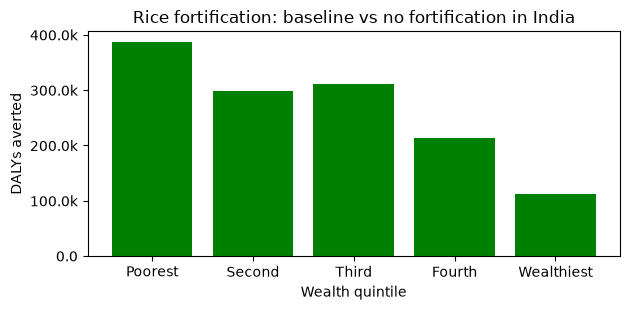

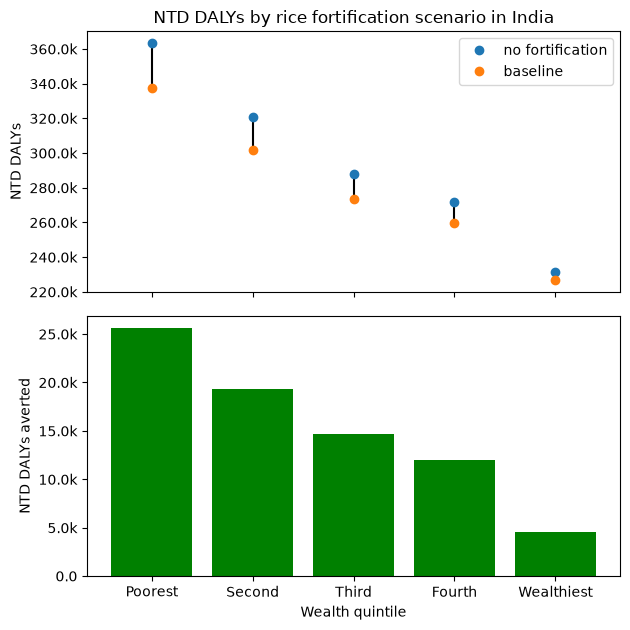

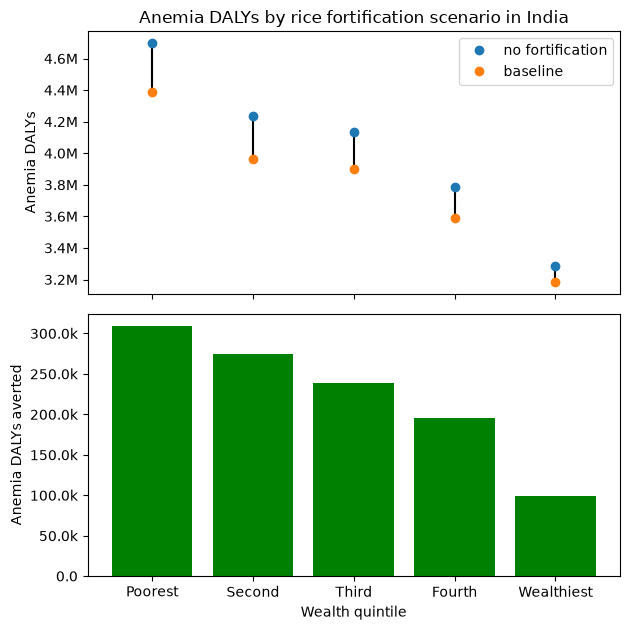

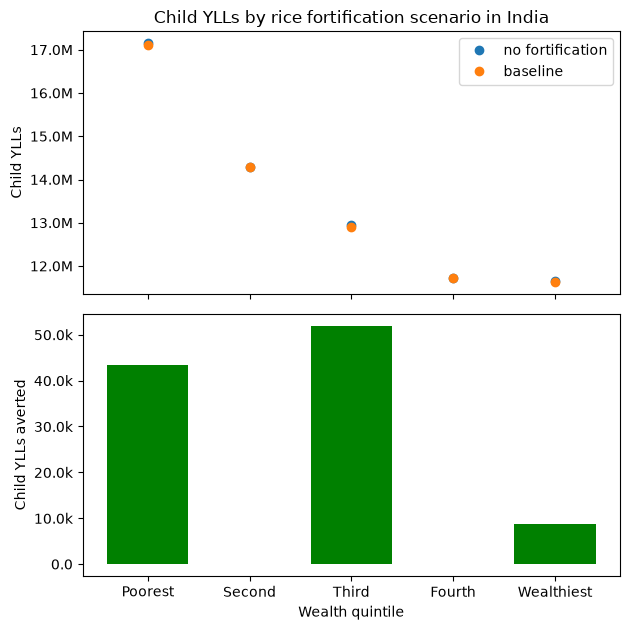

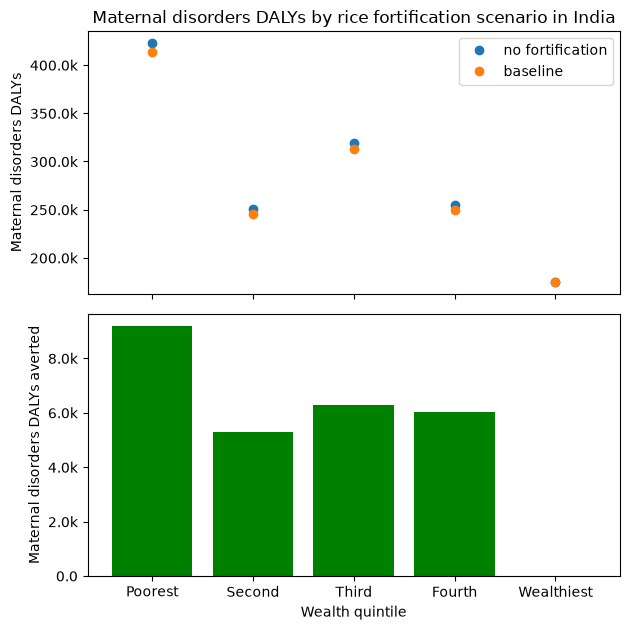

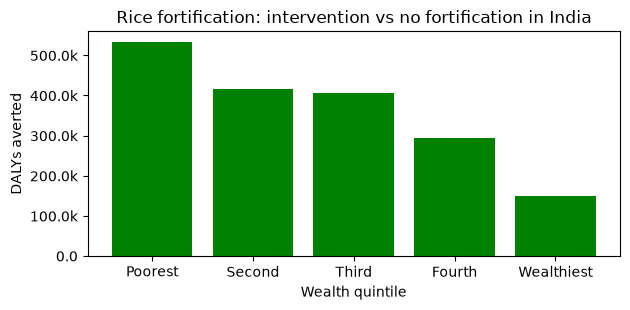

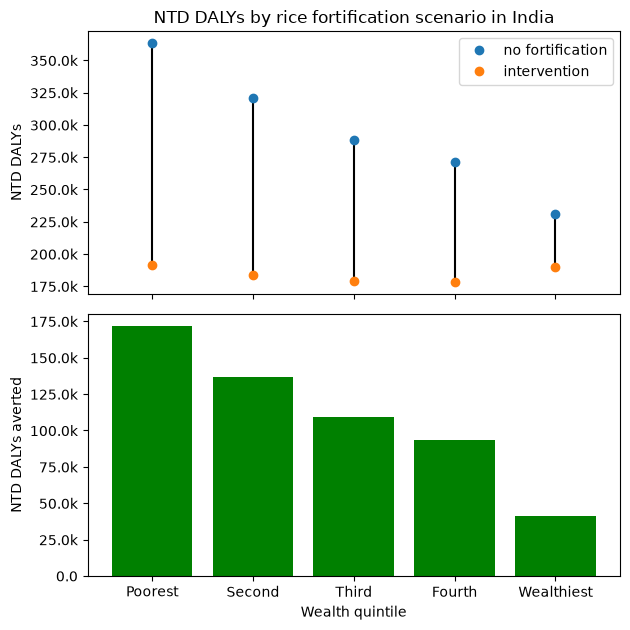

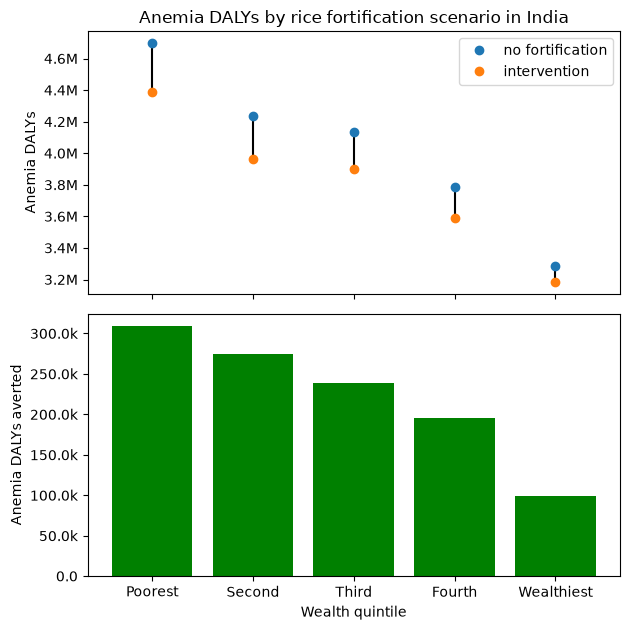

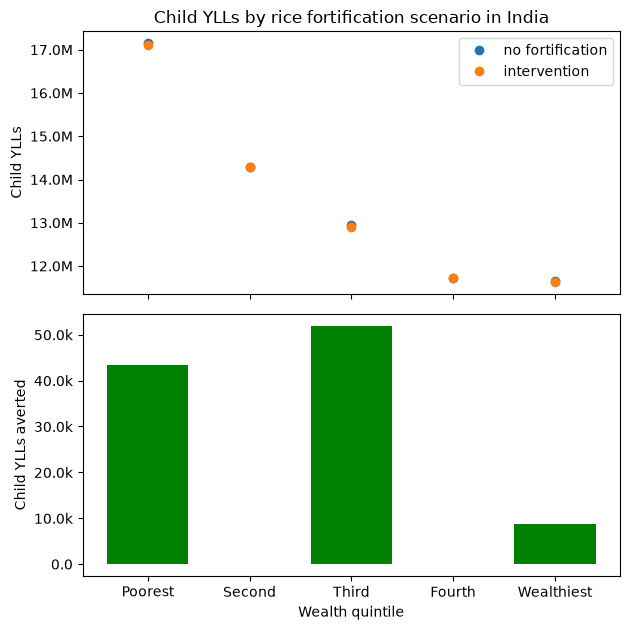

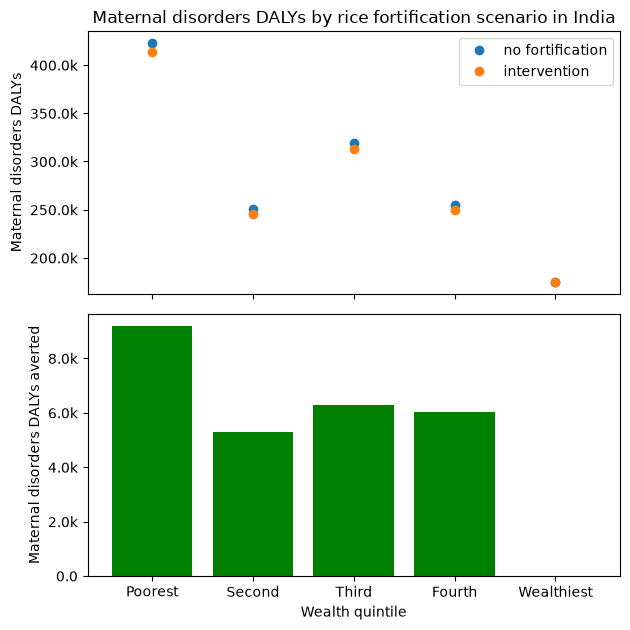

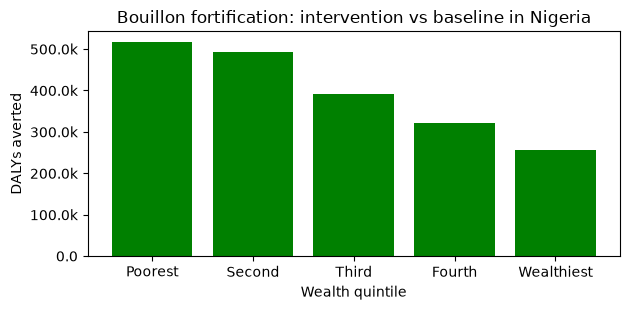

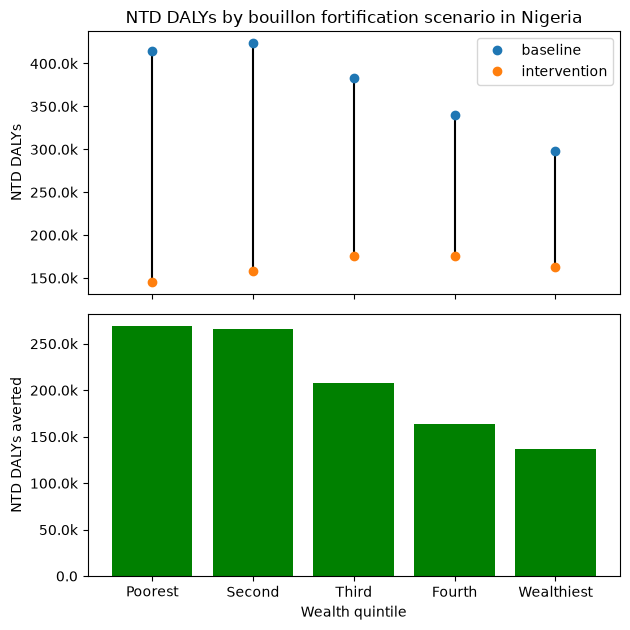

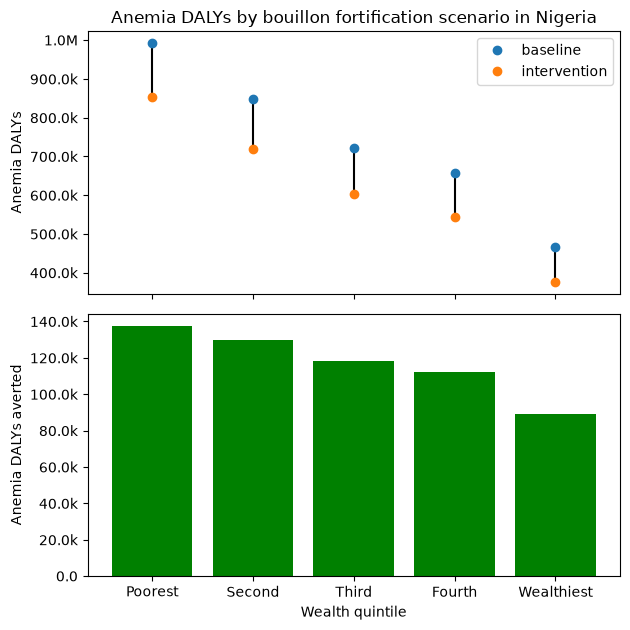

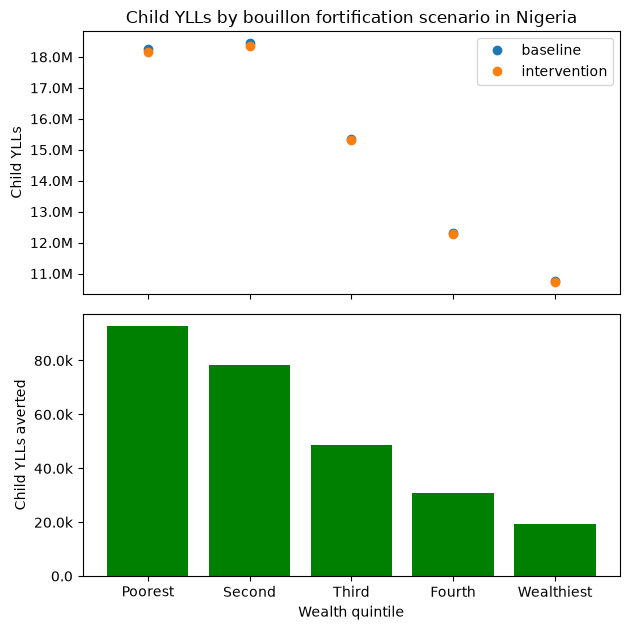

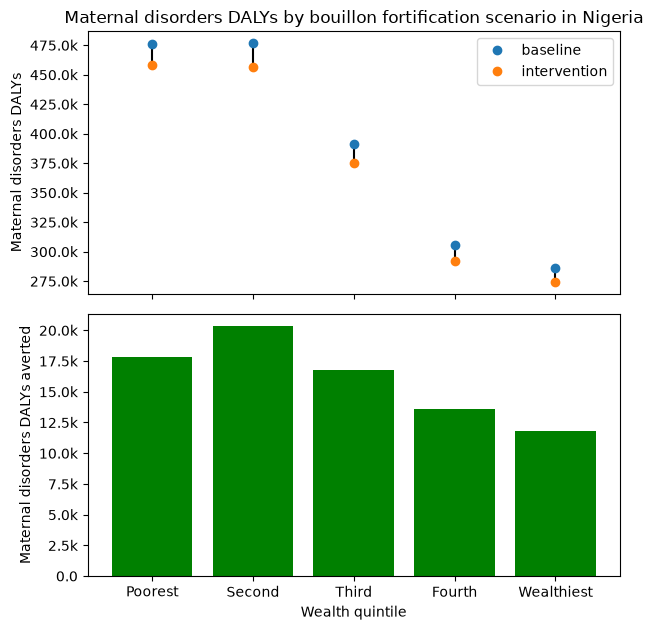

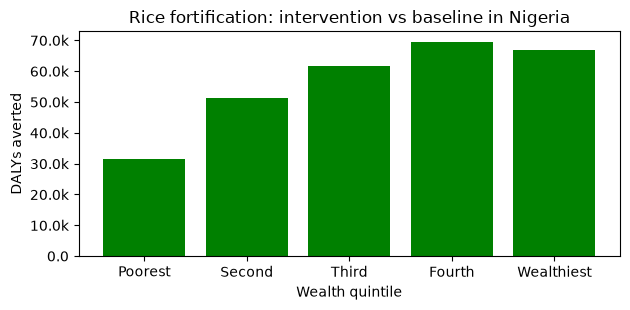

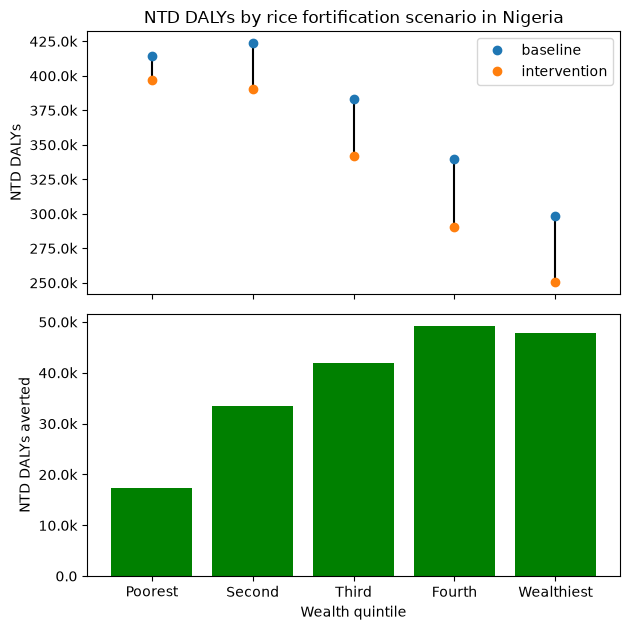

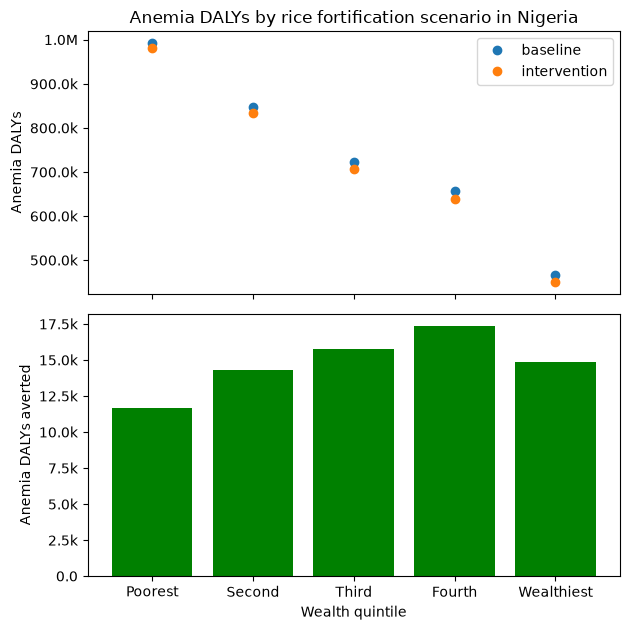

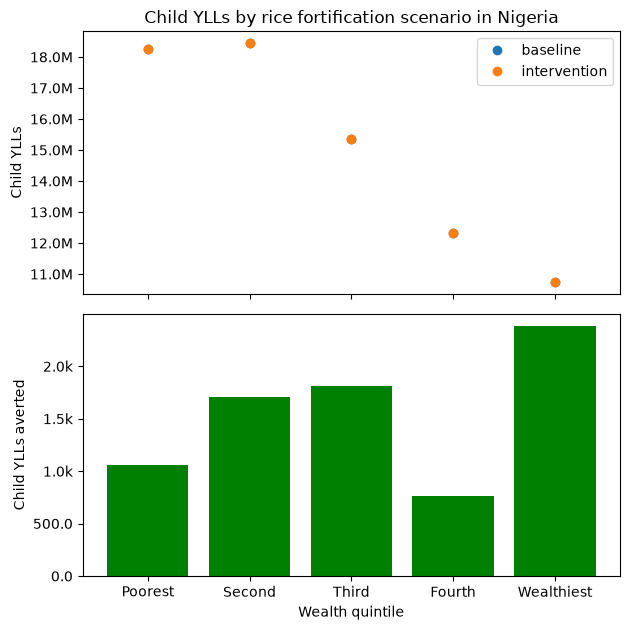

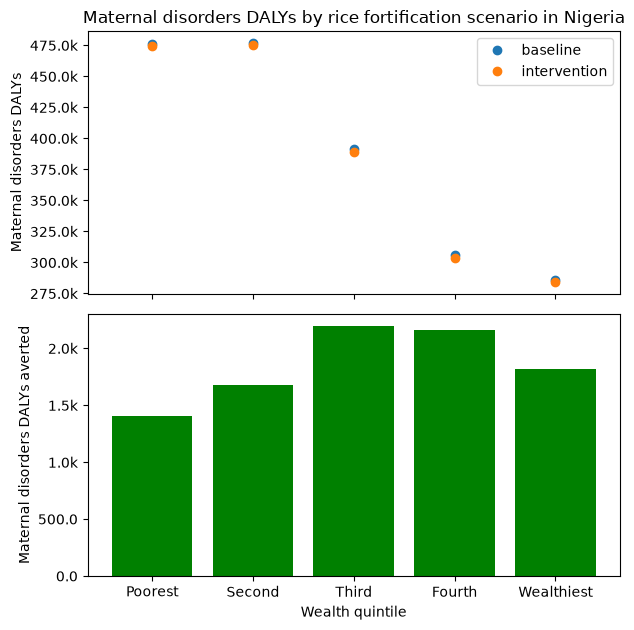

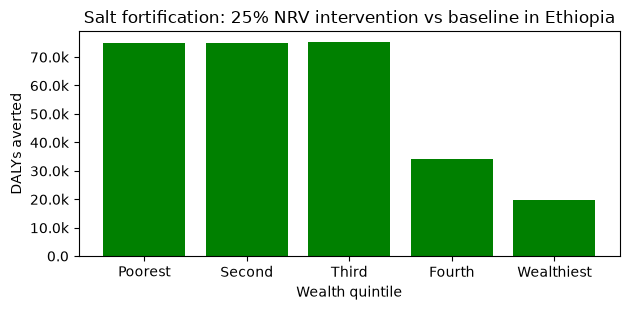

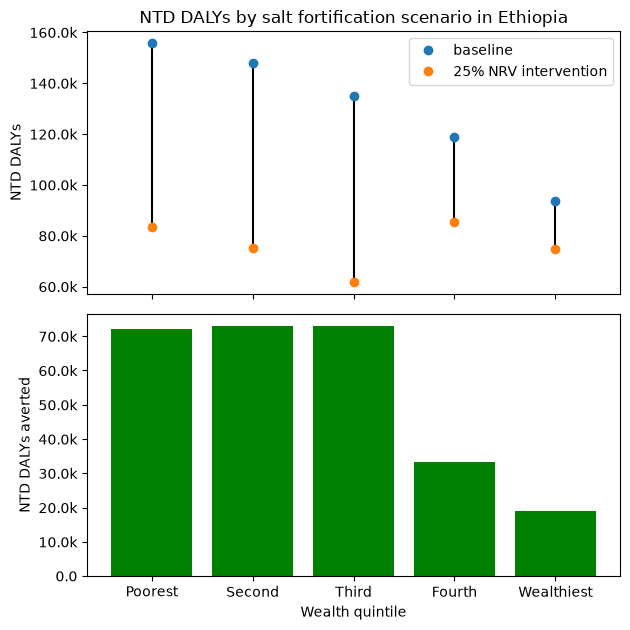

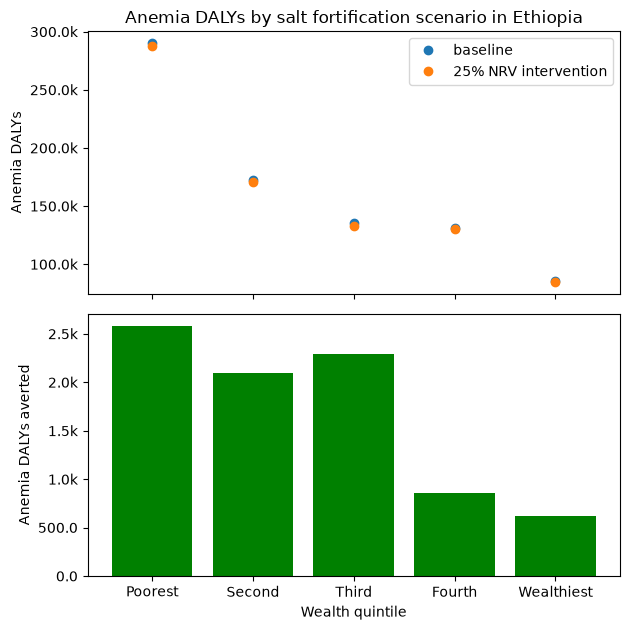

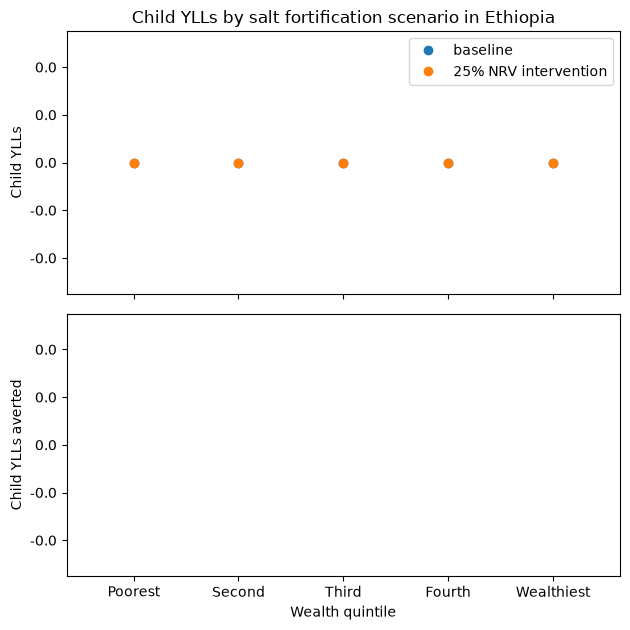

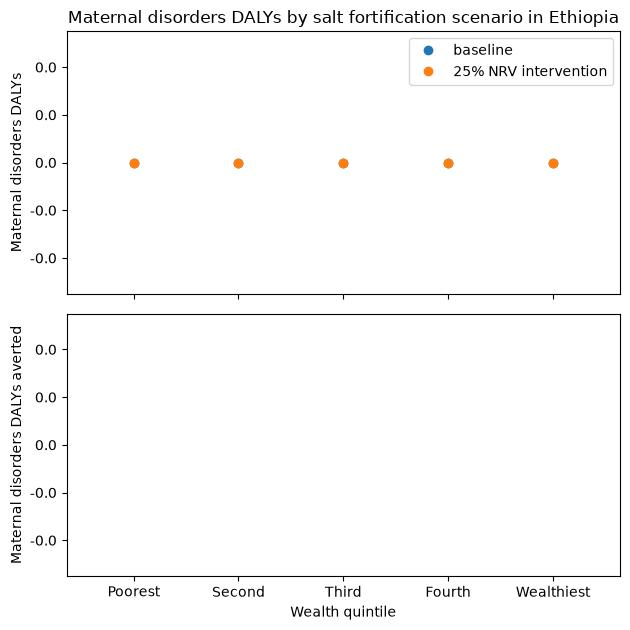

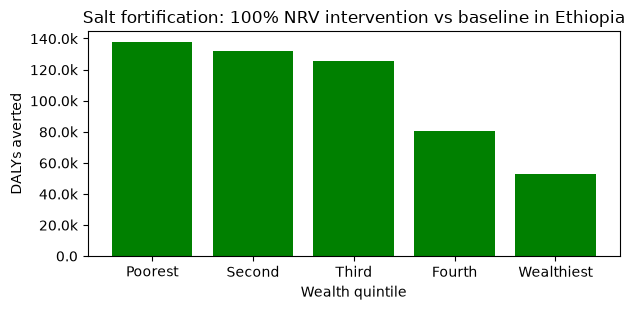

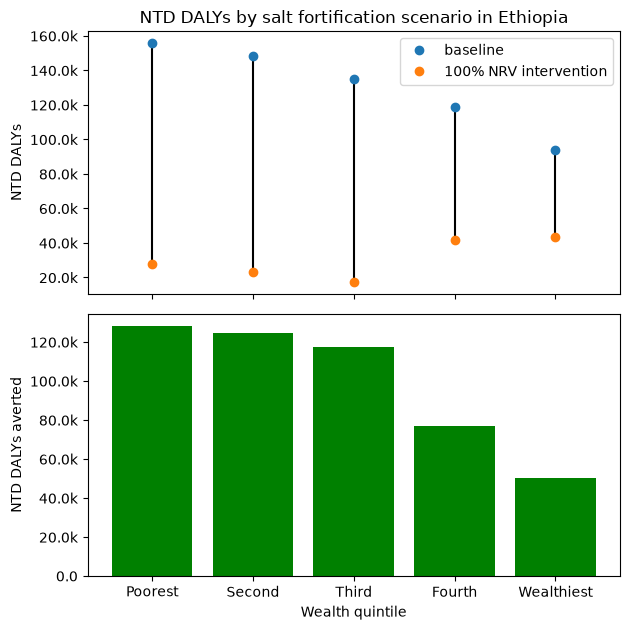

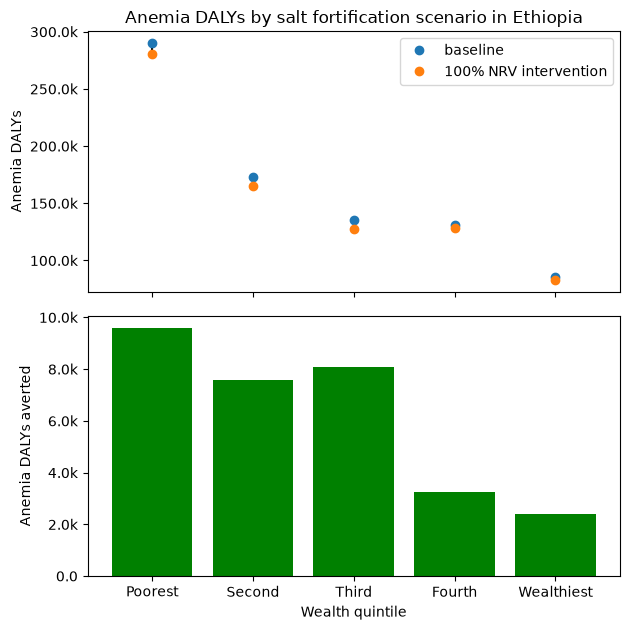

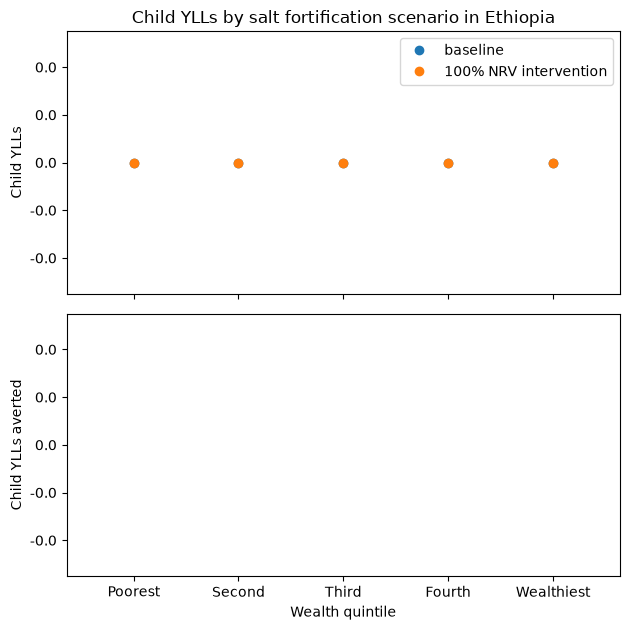

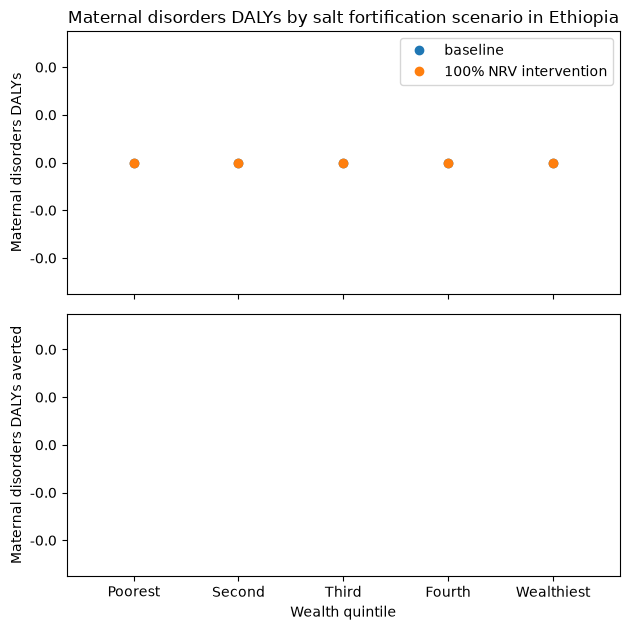

In [5]:
from matplotlib.ticker import FuncFormatter


# https://stackoverflow.com/a/61330823/
def human_format(num, pos):
    magnitude = 0
    while abs(num) >= 1000:
        magnitude += 1
        num /= 1000.0
    # add more suffixes if you need them
    scale = ["", "k", "M", "G", "T", "P"][magnitude]
    return f"{num:.1f}{scale}"


formatter = FuncFormatter(human_format)

for _, (
    location,
    vehicle,
    baseline_scenario,
    intervention_scenario,
    custom_name,
) in pd.read_csv("../0050_config/location_vehicle_scenario_comparisons.csv").iterrows():
    dalys_by_scenario = pd.read_csv(
        f"./results/{location}/{vehicle}/dalys_by_scenario.csv"
    )

    overall_dalys_by_scenario = dalys_by_scenario.groupby(
        ["scenario", "wealth_quintile"]
    )[["value"]].sum()
    baseline_overall_dalys = overall_dalys_by_scenario.loc[
        baseline_scenario
    ].reset_index()
    intervention_overall_dalys = overall_dalys_by_scenario.loc[
        intervention_scenario
    ].reset_index()
    assert set(baseline_overall_dalys.wealth_quintile.unique()) == set(
        intervention_overall_dalys.wealth_quintile.unique()
    )
    quintiles = display_quintiles.values()
    x = np.arange(len(quintiles))  # the label locations
    fig, ax = plt.subplots(figsize=[6.4, 3.2])

    averted_dalys = (
        baseline_overall_dalys.set_index("wealth_quintile").value
        - intervention_overall_dalys.set_index("wealth_quintile").value
    )

    ax.set_title(
        f"{vehicle.title()} fortification: {display_scenarios[intervention_scenario]} vs {display_scenarios[baseline_scenario]} in {location.title()}"
    )

    ax.bar(x, averted_dalys.loc[display_quintiles.keys()], color="green")

    ax.set_ylabel(f"DALYs averted")
    ax.yaxis.set_major_formatter(formatter)

    ax.set_xticks(x, quintiles)
    ax.set_xlabel("Wealth quintile")

    plt.tight_layout()
    plt.show()

    for category, category_name in daly_categories.items():
        category_dalys_by_scenario = dalys_by_scenario.set_index(
            ["entity", "scenario", "wealth_quintile"]
        ).loc[category]

        baseline_dalys = category_dalys_by_scenario.loc[baseline_scenario].reset_index()
        intervention_dalys = category_dalys_by_scenario.loc[
            intervention_scenario
        ].reset_index()
        assert set(baseline_dalys.wealth_quintile.unique()) == set(
            intervention_dalys.wealth_quintile.unique()
        )
        quintiles = display_quintiles.values()

        x = np.arange(len(quintiles))  # the label locations

        fig, (ax, ax2) = plt.subplots(nrows=2, sharex=True, figsize=[6.4, 6.4])

        ax.plot(
            np.array([[x[i], x[i], np.nan] for i in range(len(quintiles))]).flatten(),
            np.array(
                [
                    [
                        baseline_dalys.set_index("wealth_quintile").value.loc[quintile],
                        intervention_dalys.set_index("wealth_quintile").value.loc[
                            quintile
                        ],
                        np.nan,
                    ]
                    for quintile in display_quintiles.keys()
                ]
            ).flatten(),
            color="black",
        )

        ax.plot(
            x,
            baseline_dalys.set_index("wealth_quintile").value.loc[
                display_quintiles.keys()
            ],
            label=display_scenarios[baseline_scenario],
            linestyle="",
            marker="o",
        )

        ax.plot(
            x,
            intervention_dalys.set_index("wealth_quintile").value.loc[
                display_quintiles.keys()
            ],
            label=display_scenarios[intervention_scenario],
            linestyle="",
            marker="o",
        )

        ax.set_ylabel(category_name)

        ax.set_title(
            f"{category_name} by {vehicle} fortification scenario in {location.title()}"
        )
        ax.legend(loc="upper right")
        ax.yaxis.set_major_formatter(formatter)

        averted_dalys = (
            baseline_dalys.set_index("wealth_quintile").value
            - intervention_dalys.set_index("wealth_quintile").value
        )

        ax2.bar(x, averted_dalys.loc[display_quintiles.keys()], color="green")

        ax2.set_ylabel(f"{category_name} averted")
        ax2.yaxis.set_major_formatter(formatter)

        ax2.set_xticks(x, quintiles)
        ax2.set_xlabel("Wealth quintile")

        plt.tight_layout()
        plt.show()